# Aspect-Based Sentiment Analysis: Northern Territory Tourism Reviews

This notebook implements a complete ABSA pipeline for visitor reviews of 6 Northern Territory tourist attractions, collected from TripAdvisor, Reddit, and Google Maps.

**Domain**: Northern Territory (Australia) Tourism  
**Data Sources**: TripAdvisor, Reddit, Google Maps  
**Sites**: Uluru-Kata Tjuta, Alice Springs Desert Park, Kakadu National Park, Nitmiluk National Park, West MacDonnell National Park, Devils Marbles (Karlu Karlu)

## Step 1: Environment Setup

In [1]:
import os
os.environ['USE_TORCH'] = '1'
os.environ['TRANSFORMERS_NO_TF'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
INTERIM_DIR = os.path.join(BASE_DIR, 'interim')
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Interim data:  {INTERIM_DIR}')
print(f'Processed out: {PROCESSED_DIR}')
print(f'Outputs:       {OUTPUTS_DIR}')
print('\nSetup complete.')

Base directory: c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2
Interim data:  c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\interim
Processed out: c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\processed
Outputs:       c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\outputs

Setup complete.


## Step 2: Data Loading and Exploration

In [2]:
df_tripadvisor = pd.read_csv(os.path.join(INTERIM_DIR, 'tripadvisor_clean.csv'), encoding='utf-8', encoding_errors='replace')
df_reddit = pd.read_csv(os.path.join(INTERIM_DIR, 'reddit_clean.csv'), encoding='utf-8', encoding_errors='replace')
df_google = pd.read_csv(os.path.join(INTERIM_DIR, 'google_clean.csv'), encoding='utf-8', encoding_errors='replace')

print('=== Dataset Shapes ===')
for name, df in [('TripAdvisor', df_tripadvisor), ('Reddit', df_reddit), ('Google Maps', df_google)]:
    print(f'{name}: {df.shape[0]:,} rows, {df.shape[1]} columns')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Nulls:   {df.isnull().sum().to_dict()}')
    print()

=== Dataset Shapes ===
TripAdvisor: 4,292 rows, 3 columns
  Columns: ['source', 'place', 'comment']
  Nulls:   {'source': 0, 'place': 0, 'comment': 0}

Reddit: 2,853 rows, 3 columns
  Columns: ['source', 'place', 'comment']
  Nulls:   {'source': 0, 'place': 0, 'comment': 0}

Google Maps: 2,387 rows, 3 columns
  Columns: ['source', 'place', 'comment']
  Nulls:   {'source': 0, 'place': 0, 'comment': 0}



In [3]:
print('=== TripAdvisor Sample ===')
display(df_tripadvisor.head(3))
print('\n=== Reddit Sample ===')
display(df_reddit.head(3))
print('\n=== Google Maps Sample ===')
display(df_google.head(3))

=== TripAdvisor Sample ===


,source,place,comment
0,TripAdvisor,Uluru-Kata Tjuta,By which I mean 1) The Uluru base walk. Diffic...
1,TripAdvisor,Uluru-Kata Tjuta,Uluru is a special place which stands out bril...
2,TripAdvisor,Uluru-Kata Tjuta,"Incredible experience, beautiful scenery, beau..."



=== Reddit Sample ===


,source,place,comment
0,Reddit/AskAnAustralian,Alice Springs Desert Park,Alice Springs is a great town. It’s got the sm...
1,Reddit/AskAnAustralian,Alice Springs Desert Park,If your not prepared to be confronted with som...
2,Reddit/AskAnAustralian,Alice Springs Desert Park,"😂 ""outer suburbs"" you do realise Alice Springs..."



=== Google Maps Sample ===


,source,place,comment
0,GoogleMaps,Alice Springs Desert Park,TheNomad.family had a wonderful day at Desert ...
1,GoogleMaps,Alice Springs Desert Park,Get there before 10.15 so you can be seated be...
2,GoogleMaps,Alice Springs Desert Park,We went on the way back from Simpsons Gap and ...


In [4]:
print('=== Place Distribution per Source ===')
for name, df in [('TripAdvisor', df_tripadvisor), ('Reddit', df_reddit), ('Google Maps', df_google)]:
    print(f'\n{name}:')
    counts = df['place'].value_counts()
    for place, count in counts.items():
        print(f'  {place}: {count}')

=== Place Distribution per Source ===

TripAdvisor:
  Alice Springs Desert Park: 1692
  Uluru-Kata Tjuta: 1401
  West MacDonnell – Ormiston Gorge: 398
  Nitmiluk (Katherine Gorge / Nitmiluk National Park): 301
  Kakadu National Park – Gunlom Falls: 265
  Devils Marbles (Karlu Karlu): 235

Reddit:
  Uluru-Kata Tjuta: 1574
  Alice Springs Desert Park: 1073
  Kakadu Gunlom Falls: 167
  Nitmiluk (Katherine Gorge): 24
  West MacDonnell Ormiston: 10
  Devils Marbles (Karlu Karlu): 5

Google Maps:
  Alice Springs Desert Park: 500
  Uluru-Kata Tjuta: 499
  Kakadu: 497
  Nitmiluk (Katherine Gorge): 482
  Tjoritja / West MacDonnell National Park: 269
  Devils Marbles (Karlu Karlu): 140


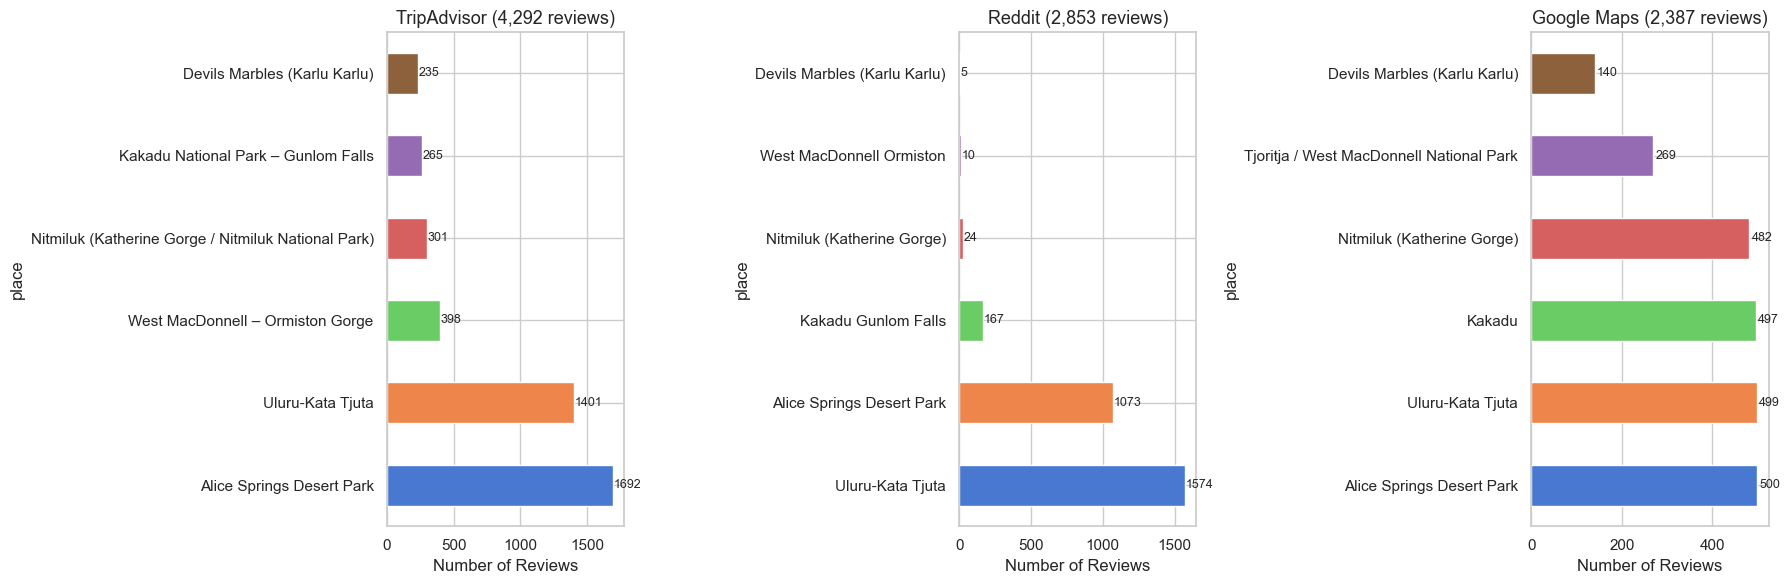

Saved: outputs/review_counts_by_source.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, df) in zip(axes, [('TripAdvisor', df_tripadvisor), ('Reddit', df_reddit), ('Google Maps', df_google)]):
    counts = df['place'].value_counts()
    counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'{name} ({df.shape[0]:,} reviews)', fontsize=13)
    ax.set_xlabel('Number of Reviews')
    for i, v in enumerate(counts.values):
        ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'review_counts_by_source.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/review_counts_by_source.png')

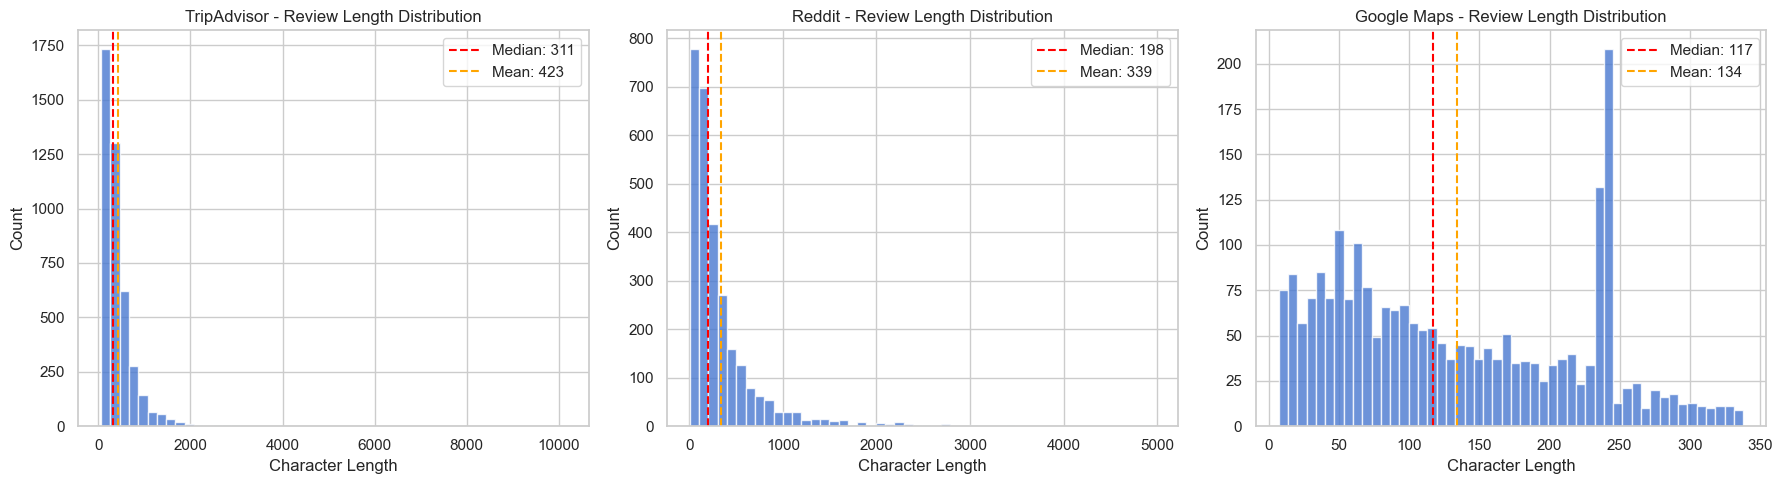

Saved: outputs/review_length_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [('TripAdvisor', df_tripadvisor), ('Reddit', df_reddit), ('Google Maps', df_google)]):
    lengths = df['comment'].astype(str).str.len()
    ax.hist(lengths, bins=50, edgecolor='white', alpha=0.8)
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'Median: {lengths.median():.0f}')
    ax.axvline(lengths.mean(), color='orange', linestyle='--', label=f'Mean: {lengths.mean():.0f}')
    ax.set_title(f'{name} - Review Length Distribution')
    ax.set_xlabel('Character Length')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'review_length_distributions.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/review_length_distributions.png')

In [7]:
print('=== Data Quality Issues ===')
for name, df in [('TripAdvisor', df_tripadvisor), ('Reddit', df_reddit), ('Google Maps', df_google)]:
    comments = df['comment'].astype(str)
    encoding_issues = comments.str.contains(r'\?T|\?o|\?\?|\ufffd|\?�', regex=True).sum()
    has_urls = comments.str.contains(r'https?://', regex=True).sum()
    has_html = comments.str.contains(r'<[^>]+>', regex=True).sum()
    very_short = (comments.str.len() < 20).sum()
    empty = comments.str.strip().eq('').sum() + df['comment'].isna().sum()
    print(f'\n{name}:')
    print(f'  Encoding artifacts:  {encoding_issues}')
    print(f'  Contains URLs:       {has_urls}')
    print(f'  Contains HTML tags:  {has_html}')
    print(f'  Very short (<20ch):  {very_short}')
    print(f'  Empty/null:          {empty}')

=== Data Quality Issues ===

TripAdvisor:
  Encoding artifacts:  12
  Contains URLs:       1
  Contains HTML tags:  0
  Very short (<20ch):  0
  Empty/null:          0

Reddit:
  Encoding artifacts:  14
  Contains URLs:       275
  Contains HTML tags:  2
  Very short (<20ch):  56
  Empty/null:          0

Google Maps:
  Encoding artifacts:  1
  Contains URLs:       0
  Contains HTML tags:  0
  Very short (<20ch):  144
  Empty/null:          0


## Step 3: Data Merging and Place Name Normalization

In [8]:
PLACE_NAME_MAP = {
    'Uluru-Kata Tjuta': 'Uluru-Kata Tjuta',
    'Alice Springs Desert Park': 'Alice Springs Desert Park',
    'Devils Marbles (Karlu Karlu)': 'Devils Marbles (Karlu Karlu)',
    'Kakadu National Park \u2013 Gunlom Falls': 'Kakadu National Park',
    'Kakadu National Park - Gunlom Falls': 'Kakadu National Park',
    'Kakadu Gunlom Falls': 'Kakadu National Park',
    'Kakadu': 'Kakadu National Park',
    'Nitmiluk (Katherine Gorge / Nitmiluk National Park)': 'Nitmiluk National Park',
    'Nitmiluk (Katherine Gorge)': 'Nitmiluk National Park',
    'West MacDonnell \u2013 Ormiston Gorge': 'West MacDonnell National Park',
    'West MacDonnell - Ormiston Gorge': 'West MacDonnell National Park',
    'West MacDonnell Ormiston': 'West MacDonnell National Park',
    'Tjoritja / West MacDonnell National Park': 'West MacDonnell National Park',
}

def normalize_place(place):
    return PLACE_NAME_MAP.get(place, place)

for df in [df_tripadvisor, df_reddit, df_google]:
    df['place'] = df['place'].apply(normalize_place)

df_all = pd.concat([df_tripadvisor, df_reddit, df_google], ignore_index=True)
df_all['comment'] = df_all['comment'].astype(str)

print(f'Merged dataset: {df_all.shape[0]:,} reviews')
print(f'\nSource distribution:')
print(df_all['source'].value_counts().to_string())
print(f'\nPlace distribution (unified):')
print(df_all['place'].value_counts().to_string())

Merged dataset: 9,532 reviews

Source distribution:
source
TripAdvisor                     4292
GoogleMaps                      2387
Reddit/australia                 809
Reddit/AskAnAustralian           634
Reddit/australian                235
Reddit/AustralianPolitics        126
Reddit/pics                      116
Reddit/AustraliaTravel            77
Reddit/todayilearned              73
Reddit/NatureIsFuckingLit         70
Reddit/darwin                     57
Reddit/geography                  50
Reddit/civ                        49
Reddit/interestingasfuck          42
Reddit/OldPhotosInRealLife        39
Reddit/PublicFreakout             33
Reddit/Damnthatsinteresting       31
Reddit/travel                     28
Reddit/Monopoly_GO                26
Reddit/worldnews                  22
Reddit/aviation                   19
Reddit/EarthPorn                  17
Reddit/hungary                    14
Reddit/AbsoluteUnits              11
Reddit/aww                        11
Reddit/Reverse19

## Step 4: Text Cleaning (Gentle Approach)

**Design decisions** (addressing instructor feedback):
- Fix encoding artifacts only (corrupted characters from scraping)
- Remove URLs/HTML but preserve all natural language
- Handle contractions for consistency
- Remove exact duplicates only — NOT near-duplicates (different people may write similar reviews at the same site)
- **Keep** weather mentions, short reviews, and emotionally charged language
- Do NOT stem, lemmatize, or remove stopwords at this stage (preserves meaning for transformer models)

In [10]:
import contractions
from bs4 import BeautifulSoup
import unicodedata

def clean_text(text):
    if pd.isna(text) or not isinstance(text, str) or text.strip() == '':
        return ''
    
    # Fix common encoding artifacts from web scraping
    text = text.replace('\ufffd', "'")
    text = re.sub(r'\?T', "'", text)             # e.g. didn?Tt -> didn't
    text = re.sub(r'\?o', '"', text)              # e.g. ?oTips?? -> "Tips"
    text = re.sub(r'\?\?', '"', text)
    text = re.sub(r'\?�', "'", text)
    text = re.sub(r'\u00e2\u0080\u0099', "'", text)
    text = re.sub(r'\u00e2\u0080\u009c', '"', text)
    text = re.sub(r'\u00e2\u0080\u009d', '"', text)
    text = re.sub(r'\u00e2\u0080\u0093', '-', text)
    text = re.sub(r'\u00e2\u0080\u0094', '-', text)
    text = re.sub(r'\u00e2\u0080\u00a6', '...', text)
    text = text.replace('\u2019', "'").replace('\u2018', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = text.replace('\u2026', '...')
    
    # Remove emoji-like codes (dY~, dY~?, dY~%, dY~?) but keep text
    text = re.sub(r'd[A-Z][~\^][^\s]{0,2}', '', text)
    
    # Remove unicode emojis
    emoji_pattern = re.compile(
        "[\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"   # symbols & pictographs
        "\U0001F680-\U0001F6FF"   # transport & map symbols
        "\U0001F900-\U0001F9FF"   # supplemental symbols
        "\U0001FA00-\U0001FA6F"   # chess symbols
        "\U0001FA70-\U0001FAFF"   # symbols extended-A
        "\u2600-\u26FF"           # misc symbols
        "\u2700-\u27BF"           # dingbats
        "\uFE00-\uFE0F"          # variation selectors
        "\u200D"                  # zero-width joiner
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    
    # Remove HTML tags
    if '<' in text:
        text = BeautifulSoup(text, 'html.parser').get_text()
    
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    
    # Remove markdown link syntax: [text](url) -> text
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    
    # Expand contractions
    try:
        text = contractions.fix(text)
    except Exception:
        pass
    
    # Normalize unicode
    text = unicodedata.normalize('NFKD', text)
    
    # Collapse excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Show before/after examples
sample_texts = [
    df_all.loc[df_all['comment'].str.contains(r"\?T", na=False), 'comment'].iloc[0] if df_all['comment'].str.contains(r"\?T", na=False).any() else '',
    df_all.loc[df_all['comment'].str.contains(r'https?://', na=False), 'comment'].iloc[0] if df_all['comment'].str.contains(r'https?://', na=False).any() else '',
]

for i, text in enumerate(sample_texts):
    if text:
        print(f'--- Example {i+1} ---')
        print(f'BEFORE: {text[:200]}...')
        print(f'AFTER:  {clean_text(text)[:200]}...')
        print()

--- Example 2 ---
BEFORE: This is a super walking trail – highly recommended for hikers!!! I was there in July 2012 and completed the circuit. Towards the southern end of the Ormiston Gorge, need to wade through an icy waterho...
AFTER:  This is a super walking trail - highly recommended for hikers!!! I was there in July 2012 and completed the circuit. Towards the southern end of the Ormiston Gorge, need to wade through an icy waterho...



In [11]:
df_clean = df_all.copy()
df_clean['comment_original'] = df_clean['comment']
df_clean['comment'] = df_clean['comment'].apply(clean_text)

# Remove empty comments after cleaning
empty_mask = df_clean['comment'].str.strip().eq('')
print(f'Empty comments after cleaning: {empty_mask.sum()}')
df_clean = df_clean[~empty_mask].reset_index(drop=True)

# Remove exact duplicates (same comment + same place + same source)
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['source', 'place', 'comment'], keep='first').reset_index(drop=True)
after_dedup = len(df_clean)
print(f'Exact duplicates removed: {before_dedup - after_dedup}')
print(f'\nFinal cleaned dataset: {df_clean.shape[0]:,} reviews')
print(f'  (started with {df_all.shape[0]:,}, removed {df_all.shape[0] - df_clean.shape[0]:,})')

Empty comments after cleaning: 5
Exact duplicates removed: 0

Final cleaned dataset: 9,527 reviews
  (started with 9,532, removed 5)


In [12]:
df_clean.to_csv(os.path.join(PROCESSED_DIR, 'cleaned_reviews.csv'), index=False)
print(f'Saved: processed/cleaned_reviews.csv ({df_clean.shape[0]:,} rows)')
display(df_clean.head())

Saved: processed/cleaned_reviews.csv (9,527 rows)


,source,place,comment,comment_original
0,TripAdvisor,Uluru-Kata Tjuta,By which I mean 1) The Uluru base walk. Diffic...,By which I mean 1) The Uluru base walk. Diffic...
1,TripAdvisor,Uluru-Kata Tjuta,Uluru is a special place which stands out bril...,Uluru is a special place which stands out bril...
2,TripAdvisor,Uluru-Kata Tjuta,"Incredible experience, beautiful scenery, beau...","Incredible experience, beautiful scenery, beau..."
3,TripAdvisor,Uluru-Kata Tjuta,I did the 4 days Uluru tour with Lost in Austr...,I did the 4 days Uluru tour with Lost in Austr...
4,TripAdvisor,Uluru-Kata Tjuta,Visiting Uluṟyou is a must for every Australi...,Visiting Uluṟu is a must for every Australian....


## Step 5: Cleaned Data Quality Report

In [13]:
print('=== Before vs After Cleaning ===')
print(f'Total reviews:  {df_all.shape[0]:,} -> {df_clean.shape[0]:,} ({df_all.shape[0] - df_clean.shape[0]:,} removed)')
print(f'  - Empty after clean: {empty_mask.sum()}')
print(f'  - Exact duplicates:  {before_dedup - after_dedup}')
print()

# Verify encoding issues are fixed
remaining_encoding = df_clean['comment'].str.contains(r'\?T|\?o', regex=True).sum()
print(f'Remaining encoding artifacts ("?T" or "?o"): {remaining_encoding}')

print(f'\nReview length statistics (cleaned):')
lengths = df_clean['comment'].str.len()
print(f'  Mean:   {lengths.mean():.0f} chars')
print(f'  Median: {lengths.median():.0f} chars')
print(f'  Min:    {lengths.min():.0f} chars')
print(f'  Max:    {lengths.max():.0f} chars')

print(f'\nReviews mentioning weather/climate (preserved): {df_clean["comment"].str.contains(r"weather|temperature|hot|cold|rain|sun|humid|wind|season|climate", case=False, regex=True).sum()}')

=== Before vs After Cleaning ===
Total reviews:  9,532 -> 9,527 (5 removed)
  - Empty after clean: 5
  - Exact duplicates:  0

Remaining encoding artifacts ("?T" or "?o"): 0

Review length statistics (cleaned):
  Mean:   323 chars
  Median: 223 chars
  Min:    1 chars
  Max:    10150 chars

Reviews mentioning weather/climate (preserved): 2458


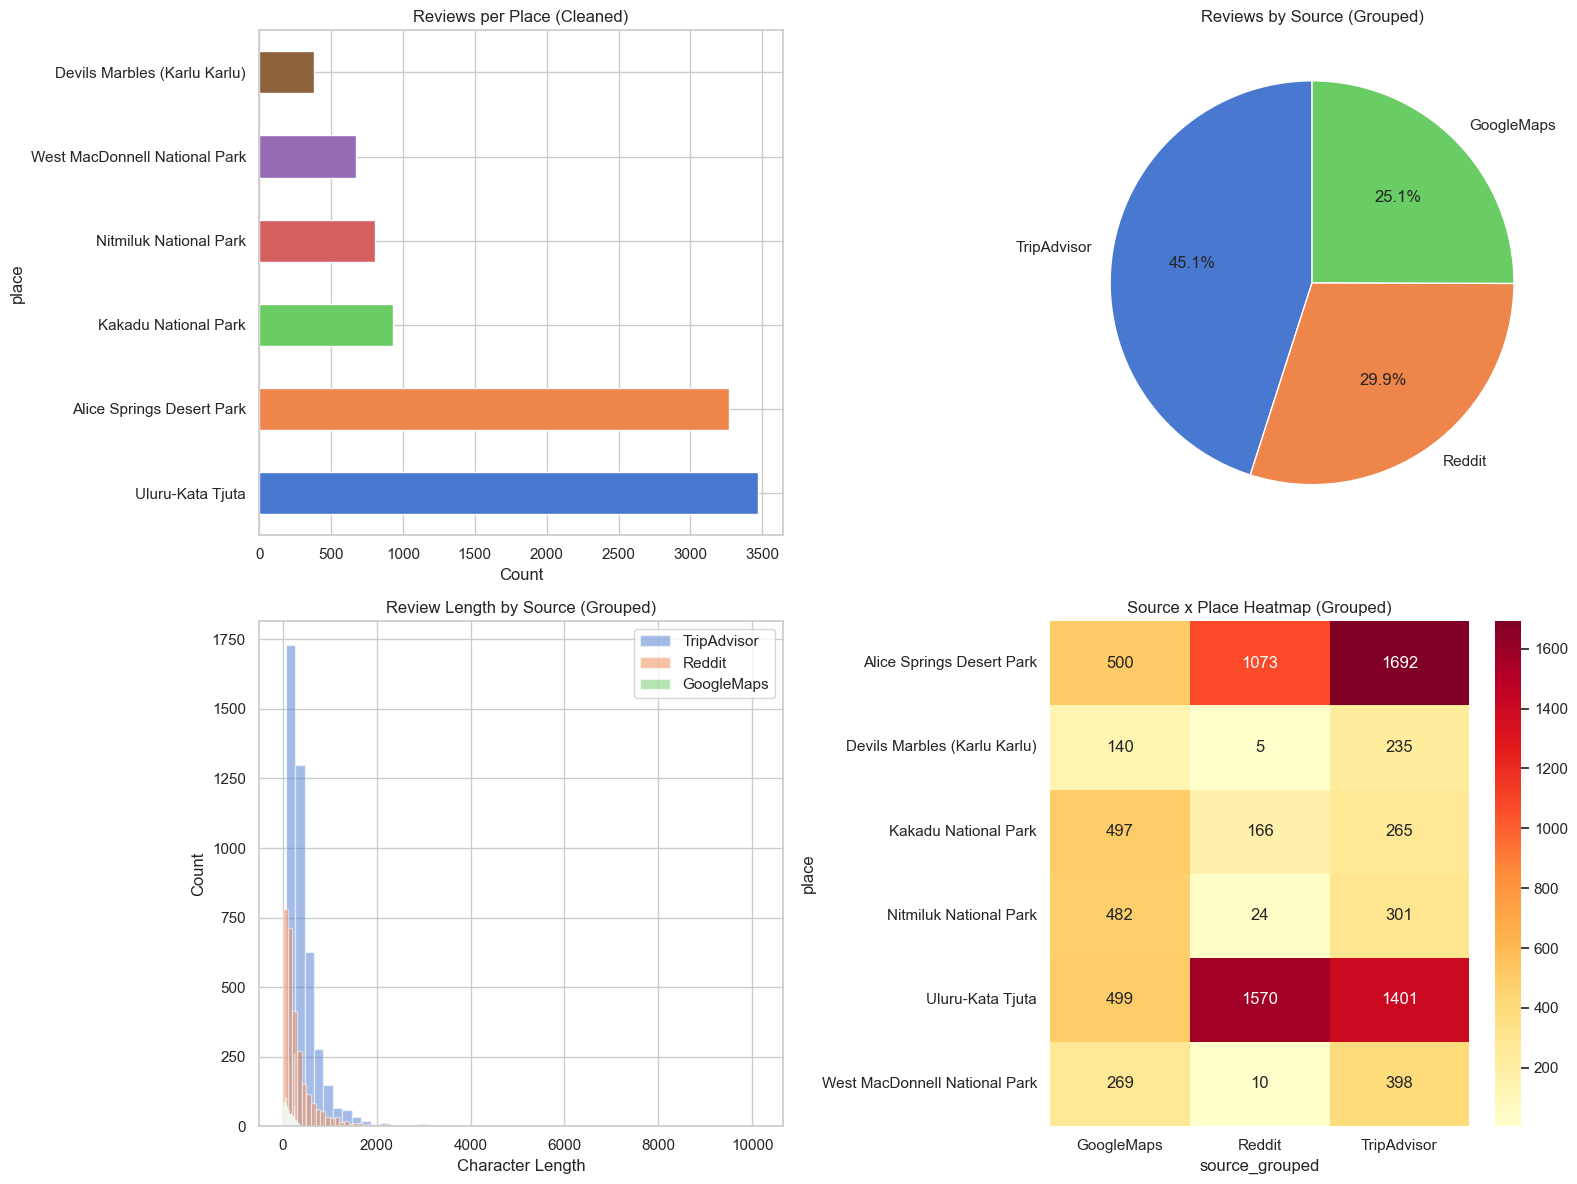

Saved: outputs/cleaned_data_quality_report.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Group all subreddit names under a single Reddit source label
df_plot = df_clean.copy()
df_plot['source_grouped'] = df_plot['source'].str.replace(r'^Reddit/.*$', 'Reddit', regex=True)

# 1. Review counts by place
ax = axes[0, 0]
df_plot['place'].value_counts().plot(kind='barh', ax=ax, color=sns.color_palette('muted', 6))
ax.set_title('Reviews per Place (Cleaned)')
ax.set_xlabel('Count')

# 2. Review counts by source (grouped)
ax = axes[0, 1]
df_plot['source_grouped'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
ax.set_title('Reviews by Source (Grouped)')
ax.set_ylabel('')

# 3. Review length distribution by source (grouped)
ax = axes[1, 0]
for src in df_plot['source_grouped'].unique():
    subset = df_plot[df_plot['source_grouped'] == src]['comment'].str.len()
    ax.hist(subset, bins=50, alpha=0.5, label=src, edgecolor='white')
ax.set_title('Review Length by Source (Grouped)')
ax.set_xlabel('Character Length')
ax.set_ylabel('Count')
ax.legend()

# 4. Crosstab heatmap (grouped)
ax = axes[1, 1]
ct = pd.crosstab(df_plot['place'], df_plot['source_grouped'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Source x Place Heatmap (Grouped)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cleaned_data_quality_report.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/cleaned_data_quality_report.png')

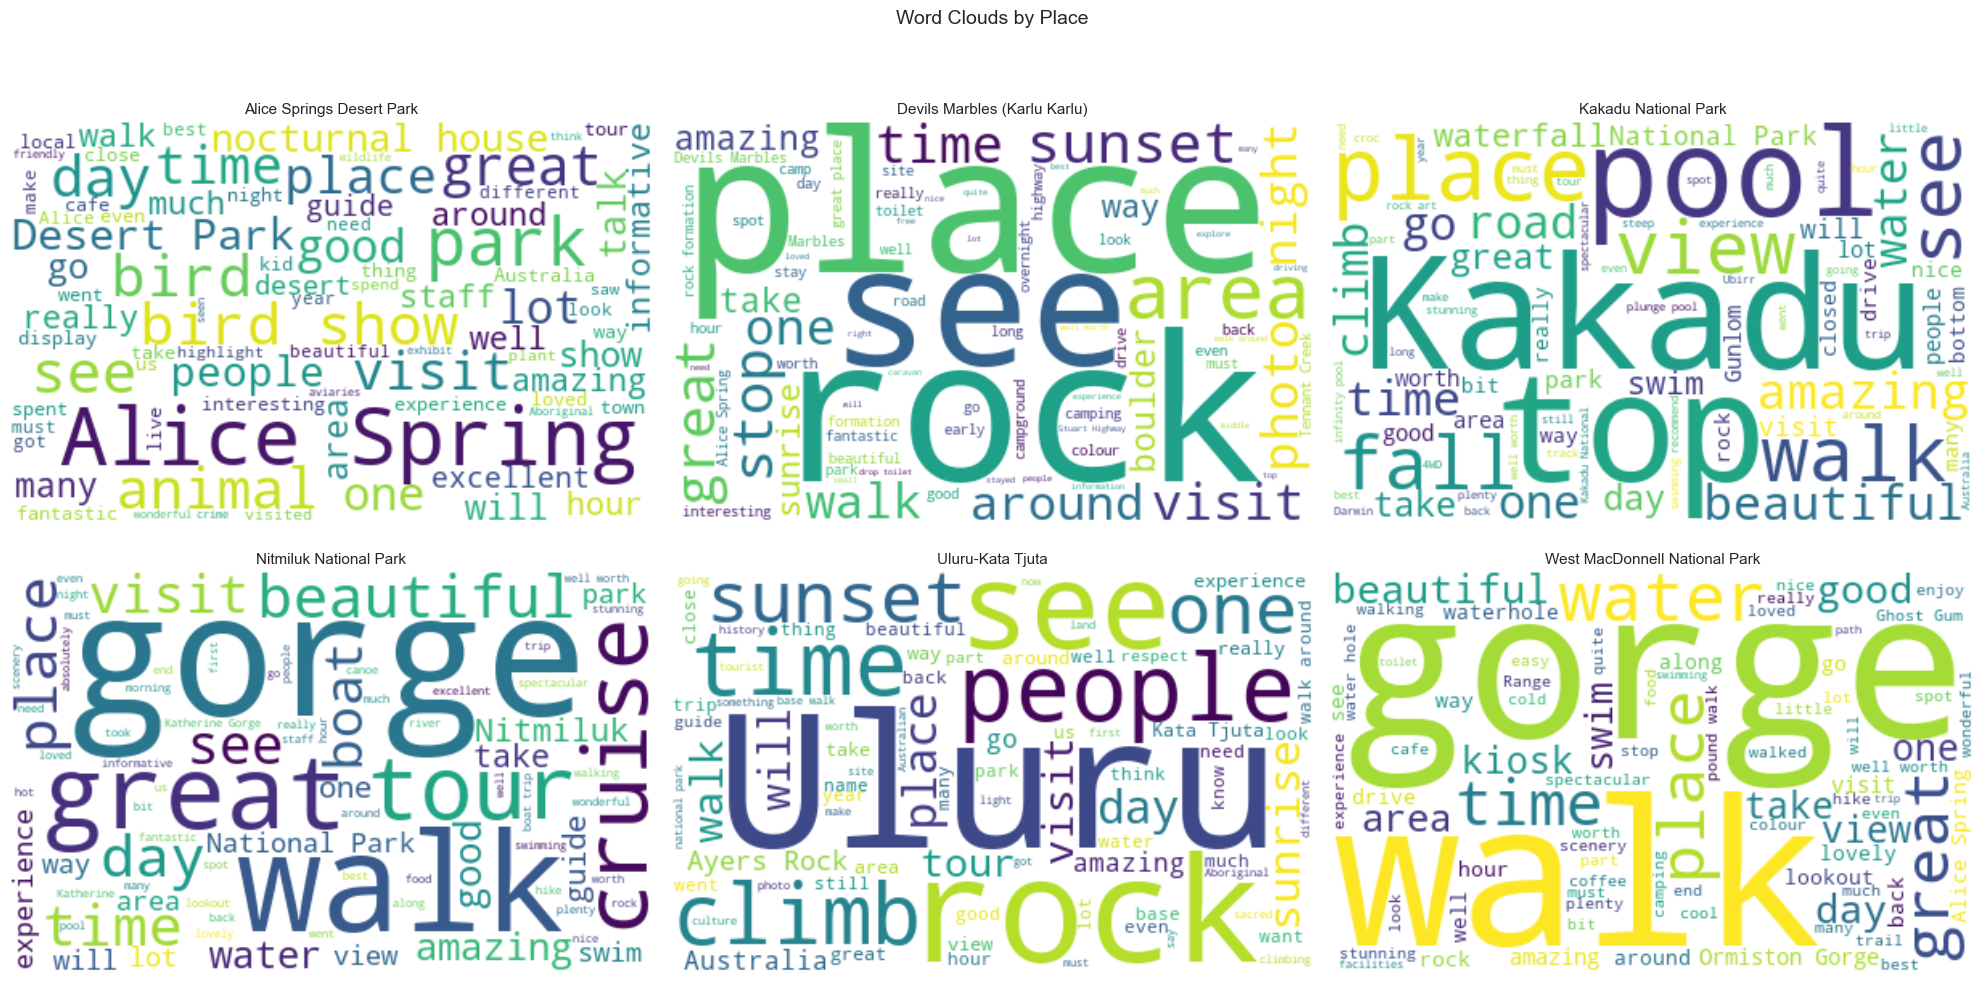

Saved: outputs/wordclouds_by_place.png


In [16]:
from wordcloud import WordCloud

places = df_clean['place'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for ax, place in zip(axes.flatten(), sorted(places)):
    text = ' '.join(df_clean[df_clean['place'] == place]['comment'].values)
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=80, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(place, fontsize=11)
    ax.axis('off')

plt.suptitle('Word Clouds by Place', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'wordclouds_by_place.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/wordclouds_by_place.png')

## Step 6: Aspect Taxonomy Development (Manual / Domain-Driven)

### Methodology
The aspect categories below were developed through **manual domain analysis**, NOT learned from pre-annotated data. The process:

1. Read ~100 reviews across all 6 sites and 3 sources to identify recurring themes
2. Grouped themes into coherent categories based on tourism domain knowledge
3. Defined seed keywords for each aspect from the reviews themselves
4. Refined categories by merging overlapping themes and splitting overly broad ones

### Justification for Each Aspect

| Aspect | Why Included | Example from Data |
|--------|-------------|-------------------|
| **Scenery/Landscape** | Core reason visitors go to NT sites | "breathtaking sights", "colours change" |
| **Cultural Experience** | Indigenous heritage is central to NT tourism | "Dreamtime stories", "aboriginal culture" |
| **Guides/Staff** | Tour quality depends heavily on guides | "guide was knowledgeable", "staff were great" |
| **Activities/Walks** | Main visitor activities at all sites | "base walk", "Kings Canyon hike" |
| **Accessibility/Facilities** | Infrastructure affects visitor experience | "well maintained", "parking", "signage" |
| **Weather/Climate** | Directly impacts NT tourism experience | "43 degrees", "flies", "best in winter" |
| **Value/Cost** | Pricing is a recurring discussion topic | "$200 per head", "3 day pass" |
| **Safety** | Significant theme esp. for Alice Springs | "don't go out at night", "heat exhaustion" |
| **Food/Dining** | Often mentioned in tour and area reviews | "camp meals", "cafe", "great cook" |
| **Accommodation** | Key logistics topic for multi-day visits | "camping", "swags", "resort", "hotel" |

In [17]:
ASPECT_KEYWORDS = {
    'Scenery/Landscape': [
        'view', 'views', 'scenery', 'scenic', 'landscape', 'beautiful', 'stunning',
        'breathtaking', 'spectacular', 'magnificent', 'gorge', 'canyon', 'rock',
        'formation', 'waterfall', 'sunset', 'sunrise', 'colour', 'color', 'colours',
        'colors', 'red centre', 'outback', 'nature', 'natural', 'lookout', 'panoramic',
        'dome', 'domes', 'stars', 'night sky', 'sky', 'mountain', 'range', 'ranges'
    ],
    'Cultural Experience': [
        'indigenous', 'aboriginal', 'anangu', 'dreamtime', 'culture', 'cultural',
        'sacred', 'spiritual', 'history', 'heritage', 'art', 'painting', 'paintings',
        'dot painting', 'cave painting', 'rock art', 'ceremony', 'traditional',
        'first nations', 'first nation', 'elders', 'custodian', 'stories', 'lore',
        'mala walk', 'gallery', 'cultural centre', 'museum'
    ],
    'Guides/Staff': [
        'guide', 'guides', 'tour guide', 'ranger', 'rangers', 'staff', 'host',
        'instructor', 'knowledgeable', 'informative', 'entertaining', 'friendly',
        'helpful', 'keeper', 'keepers', 'presenter', 'presentation', 'talk', 'talks',
        'explained', 'explanation'
    ],
    'Activities/Walks': [
        'walk', 'walks', 'hike', 'hiking', 'trek', 'trekking', 'trail', 'trails',
        'track', 'tracks', 'base walk', 'rim walk', 'swimming', 'swim', 'kayak',
        'canoe', 'cruise', 'boat', 'tour', 'tours', 'excursion', 'adventure',
        'climb', 'climbing', 'camp', 'camping', 'campfire', 'swag', 'swags',
        'bird show', 'feeding', 'camel', 'drone show', 'field of lights'
    ],
    'Accessibility/Facilities': [
        'parking', 'car park', 'toilet', 'toilets', 'bathroom', 'restroom', 'facility',
        'facilities', 'path', 'paths', 'accessible', 'wheelchair', 'signage', 'sign',
        'signs', 'maintained', 'infrastructure', 'bus', 'shuttle', 'transport',
        'hop on', 'hop off', 'visitor centre', 'visitor center', 'information',
        'map', 'maps', 'sealed road', 'gravel road', 'road', 'drive', 'driving'
    ],
    'Weather/Climate': [
        'weather', 'temperature', 'hot', 'heat', 'cold', 'warm', 'cool', 'rain',
        'rainy', 'wet', 'dry', 'humid', 'humidity', 'wind', 'windy', 'sun', 'sunny',
        'shade', 'shade', 'season', 'winter', 'summer', 'flies', 'fly', 'flynet',
        'mosquito', 'mosquitoes', 'degree', 'degrees', 'celsius', 'climate', 'scorching'
    ],
    'Value/Cost': [
        'price', 'prices', 'cost', 'costs', 'expensive', 'cheap', 'affordable',
        'value', 'worth', 'money', 'fee', 'fees', 'ticket', 'tickets', 'entry',
        'admission', 'pass', 'budget', 'free', 'pay', 'paid', 'overpriced',
        'dollar', 'dollars', '$'
    ],
    'Safety': [
        'safe', 'safety', 'unsafe', 'danger', 'dangerous', 'crime', 'criminal',
        'risk', 'risky', 'security', 'secure', 'theft', 'stolen', 'attack',
        'violent', 'violence', 'aggressive', 'harassed', 'harassment', 'threat',
        'police', 'locked', 'gated', 'dehydration', 'heat exhaustion', 'heat stroke',
        'emergency', 'caution', 'warning', 'careful'
    ],
    'Food/Dining': [
        'food', 'meal', 'meals', 'restaurant', 'restaurants', 'cafe', 'coffee',
        'breakfast', 'lunch', 'dinner', 'eat', 'eating', 'cook', 'cooking', 'chef',
        'menu', 'delicious', 'tasty', 'bbq', 'barbecue', 'picnic', 'snack',
        'pie', 'pies', 'bakery', 'bar', 'drinks', 'wine', 'beer', 'catering'
    ],
    'Accommodation': [
        'hotel', 'hotels', 'resort', 'resorts', 'motel', 'hostel', 'lodge',
        'accommodation', 'room', 'rooms', 'bed', 'beds', 'stay', 'stayed',
        'night', 'nights', 'check in', 'checkout', 'sleep', 'sleeping',
        'campsite', 'campground', 'tent', 'cabin', 'bunk', 'dorm', 'pool',
        'amenities', 'shower', 'kitchen'
    ]
}

print(f'Defined {len(ASPECT_KEYWORDS)} aspects with keyword dictionaries:')
for aspect, keywords in ASPECT_KEYWORDS.items():
    print(f'  {aspect}: {len(keywords)} seed terms')

Defined 10 aspects with keyword dictionaries:
  Scenery/Landscape: 35 seed terms
  Cultural Experience: 28 seed terms
  Guides/Staff: 21 seed terms
  Activities/Walks: 34 seed terms
  Accessibility/Facilities: 32 seed terms
  Weather/Climate: 32 seed terms
  Value/Cost: 25 seed terms
  Safety: 30 seed terms
  Food/Dining: 30 seed terms
  Accommodation: 30 seed terms


## Step 7: Rule-Based Aspect Extraction

This rule-based system was designed by the author (not borrowed from an existing library). It uses:
1. **Keyword matching** against the aspect dictionaries defined in Step 6
2. **spaCy dependency parsing** to link aspect terms to opinion words in the same clause
3. **Sentence-level extraction** so that multi-aspect reviews are handled correctly

In [19]:
import spacy

nlp = spacy.load('en_core_web_sm')

# Precompile regex patterns for each aspect
ASPECT_PATTERNS = {}
for aspect, keywords in ASPECT_KEYWORDS.items():
    escaped = [re.escape(kw) for kw in keywords]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b', re.IGNORECASE)
    ASPECT_PATTERNS[aspect] = pattern

OPINION_WORDS = {
    'positive': [
        'amazing', 'awesome', 'beautiful', 'best', 'brilliant', 'excellent',
        'fabulous', 'fantastic', 'good', 'gorgeous', 'great', 'impressive',
        'incredible', 'lovely', 'magnificent', 'nice', 'outstanding', 'perfect',
        'recommend', 'stunning', 'superb', 'unforgettable', 'wonderful', 'worth',
        'love', 'loved', 'enjoy', 'enjoyed', 'delightful', 'magical', 'special',
        'clean', 'comfortable', 'convenient', 'friendly', 'helpful', 'informative',
        'knowledgeable', 'pleasant', 'satisfying', 'welcoming'
    ],
    'negative': [
        'awful', 'bad', 'boring', 'crowded', 'dangerous', 'disappointing',
        'disappointed', 'dirty', 'expensive', 'horrible', 'mediocre', 'noisy',
        'overpriced', 'poor', 'rude', 'terrible', 'ugly', 'uncomfortable',
        'unfriendly', 'unhelpful', 'unpleasant', 'unsafe', 'waste', 'worst',
        'avoid', 'broken', 'closed', 'dated', 'filthy', 'lack', 'lacking',
        'limited', 'overcrowded', 'rough', 'run down', 'scary', 'slow'
    ]
}

def extract_aspects_rule_based(text):
    """Extract aspects and their sentiment from a review using rule-based approach."""
    results = []
    doc = nlp(text)
    
    for sent in doc.sents:
        sent_text = sent.text.lower()
        matched_aspects = []
        
        for aspect, pattern in ASPECT_PATTERNS.items():
            matches = pattern.findall(sent_text)
            if matches:
                matched_aspects.append((aspect, matches))
        
        if not matched_aspects:
            continue
        
        # Determine sentiment from opinion words and negation
        words = sent_text.split()
        has_negation = any(w in ['not', 'no', 'never', 'neither', 'nor', "n't",
                                  'hardly', 'barely', 'scarcely', 'without']
                          for w in words)
        
        pos_count = sum(1 for w in words if w in OPINION_WORDS['positive'])
        neg_count = sum(1 for w in words if w in OPINION_WORDS['negative'])
        
        if has_negation:
            pos_count, neg_count = neg_count, pos_count
        
        if pos_count > neg_count:
            sentiment = 'positive'
        elif neg_count > pos_count:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
        
        for aspect, matches in matched_aspects:
            results.append({
                'aspect': aspect,
                'sentiment': sentiment,
                'matched_terms': matches,
                'sentence': sent.text.strip()
            })
    
    return results

# Test on a few examples
test_reviews = [
    "The sunset views were absolutely stunning and the guides were very knowledgeable.",
    "It was extremely hot and the flies were terrible, but the gorge was beautiful.",
    "Overpriced tickets for what you get. The cafe food was mediocre at best.",
    "Learned so much about Aboriginal culture. The cave paintings were incredible."
]

for review in test_reviews:
    print(f'Review: "{review}"')
    aspects = extract_aspects_rule_based(review)
    for a in aspects:
        print(f'  -> {a["aspect"]} ({a["sentiment"]}): matched [{", ".join(a["matched_terms"])}]')
    print()

Review: "The sunset views were absolutely stunning and the guides were very knowledgeable."
  -> Scenery/Landscape (positive): matched [sunset, views, stunning]
  -> Guides/Staff (positive): matched [guides, knowledgeable]

Review: "It was extremely hot and the flies were terrible, but the gorge was beautiful."
  -> Scenery/Landscape (neutral): matched [gorge, beautiful]
  -> Weather/Climate (neutral): matched [hot, flies]

Review: "Overpriced tickets for what you get. The cafe food was mediocre at best."
  -> Value/Cost (negative): matched [overpriced, tickets]
  -> Food/Dining (negative): matched [cafe, food]

Review: "Learned so much about Aboriginal culture. The cave paintings were incredible."
  -> Cultural Experience (neutral): matched [aboriginal, culture]
  -> Cultural Experience (neutral): matched [paintings]



In [20]:
print('Running rule-based extraction on full corpus...')
all_extractions = []

for idx, row in df_clean.iterrows():
    aspects = extract_aspects_rule_based(row['comment'])
    for a in aspects:
        all_extractions.append({
            'review_idx': idx,
            'source': row['source'],
            'place': row['place'],
            'aspect': a['aspect'],
            'sentiment': a['sentiment'],
            'matched_terms': ', '.join(a['matched_terms']),
            'sentence': a['sentence']
        })
    
    if (idx + 1) % 2000 == 0:
        print(f'  Processed {idx + 1:,} / {len(df_clean):,} reviews...')

df_aspects = pd.DataFrame(all_extractions)
print(f'\nExtraction complete: {len(df_aspects):,} aspect-sentiment pairs from {df_clean.shape[0]:,} reviews')

reviews_with_aspects = df_aspects['review_idx'].nunique()
print(f'Reviews with at least one aspect: {reviews_with_aspects:,} ({reviews_with_aspects/len(df_clean)*100:.1f}%)')
print(f'Reviews with no aspect detected: {len(df_clean) - reviews_with_aspects:,}')

Running rule-based extraction on full corpus...
  Processed 2,000 / 9,527 reviews...
  Processed 4,000 / 9,527 reviews...
  Processed 6,000 / 9,527 reviews...
  Processed 8,000 / 9,527 reviews...

Extraction complete: 31,740 aspect-sentiment pairs from 9,527 reviews
Reviews with at least one aspect: 7,919 (83.1%)
Reviews with no aspect detected: 1,608


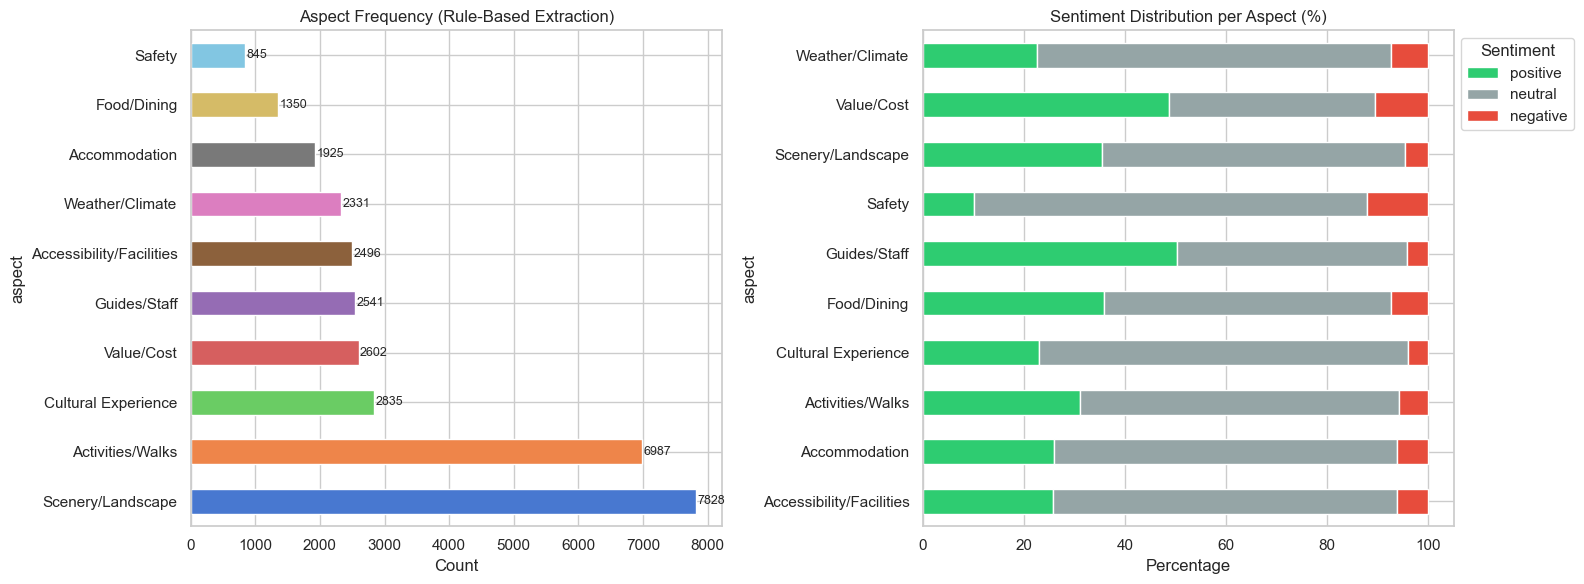

Saved: outputs/rule_based_aspect_extraction.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aspect frequency
ax = axes[0]
aspect_counts = df_aspects['aspect'].value_counts()
aspect_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(aspect_counts)))
ax.set_title('Aspect Frequency (Rule-Based Extraction)')
ax.set_xlabel('Count')
for i, v in enumerate(aspect_counts.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=9)

# Sentiment distribution per aspect
ax = axes[1]
ct = pd.crosstab(df_aspects['aspect'], df_aspects['sentiment'], normalize='index') * 100
ct = ct.reindex(columns=['positive', 'neutral', 'negative'])
ct.plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#95a5a6', '#e74c3c'])
ax.set_title('Sentiment Distribution per Aspect (%)')
ax.set_xlabel('Percentage')
ax.legend(title='Sentiment', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'rule_based_aspect_extraction.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/rule_based_aspect_extraction.png')

In [22]:
df_aspects.to_csv(os.path.join(OUTPUTS_DIR, 'aspect_extraction_results.csv'), index=False)
print(f'Saved: outputs/aspect_extraction_results.csv ({len(df_aspects):,} rows)')

# Show aspect distribution by place
print('\n=== Aspect Distribution by Place ===')
place_aspect_ct = pd.crosstab(df_aspects['place'], df_aspects['aspect'])
display(place_aspect_ct)

Saved: outputs/aspect_extraction_results.csv (31,740 rows)

=== Aspect Distribution by Place ===


aspect,Accessibility/Facilities,Accommodation,Activities/Walks,Cultural Experience,Food/Dining,Guides/Staff,Safety,Scenery/Landscape,Value/Cost,Weather/Climate
place,,,,,,,,,,
Alice Springs Desert Park,618,455,1624,716,488,1619,604,956,935,508
Devils Marbles (Karlu Karlu),206,148,210,35,23,11,5,276,139,82
Kakadu National Park,355,334,688,198,78,83,46,637,259,231
Nitmiluk National Park,189,132,923,121,181,225,29,892,181,168
Uluru-Kata Tjuta,899,734,2825,1746,410,551,151,4238,972,1124
West MacDonnell National Park,229,122,717,19,170,52,10,829,116,218


## Step 8: Gold Standard Annotation Sample

Stratified sample of 300 reviews annotated with rule-based extraction, to be used as a gold standard for model evaluation. In a production setting, these would be human-annotated; here we create the sample and evaluate the rule-based system's coverage.

In [23]:
np.random.seed(42)

# Stratified sample: ~50 per place, balanced across sources where possible
sample_dfs = []
for place in df_clean['place'].unique():
    place_df = df_clean[df_clean['place'] == place]
    n_per_place = min(50, len(place_df))
    
    source_groups = place_df.groupby('source')
    n_per_source = max(1, n_per_place // len(source_groups))
    
    for source, group in source_groups:
        n_sample = min(n_per_source, len(group))
        sample_dfs.append(group.sample(n=n_sample, random_state=42))

df_sample = pd.concat(sample_dfs, ignore_index=True)
print(f'Gold standard sample: {len(df_sample)} reviews')
print(f'\nDistribution:')
print(pd.crosstab(df_sample['place'], df_sample['source'], margins=True))

Gold standard sample: 183 reviews

Distribution:
source                         GoogleMaps  Reddit/4x4Australia  Reddit/ABCaus  \
place                                                                           
Alice Springs Desert Park               1                    0              1   
Devils Marbles (Karlu Karlu)            8                    0              0   
Kakadu National Park                    1                    1              0   
Nitmiluk National Park                  3                    0              0   
Uluru-Kata Tjuta                        1                    0              0   
West MacDonnell National Park           6                    0              0   
All                                    20                    1              1   

source                         Reddit/AFL  Reddit/AITAH  Reddit/AbsoluteUnits  \
place                                                                           
Alice Springs Desert Park               1             0    

In [24]:
# Annotate sample with rule-based system
sample_annotations = []

for idx, row in df_sample.iterrows():
    aspects = extract_aspects_rule_based(row['comment'])
    if aspects:
        aspect_list = list(set(a['aspect'] for a in aspects))
        sentiment_list = [a['sentiment'] for a in aspects]
        dominant_sentiment = max(set(sentiment_list), key=sentiment_list.count)
    else:
        aspect_list = ['none_detected']
        dominant_sentiment = 'neutral'
    
    sample_annotations.append({
        'source': row['source'],
        'place': row['place'],
        'comment': row['comment'],
        'aspects_detected': '; '.join(aspect_list),
        'num_aspects': len(aspect_list) if aspect_list[0] != 'none_detected' else 0,
        'dominant_sentiment': dominant_sentiment,
        'human_aspects': '',
        'human_sentiment': ''
    })

df_annotated = pd.DataFrame(sample_annotations)
df_annotated.to_csv(os.path.join(PROCESSED_DIR, 'annotated_sample.csv'), index=False)
print(f'Saved: processed/annotated_sample.csv ({len(df_annotated)} rows)')
print(f'\nAspect detection rate: {(df_annotated["num_aspects"] > 0).mean()*100:.1f}%')
print(f'Average aspects per review: {df_annotated["num_aspects"].mean():.2f}')
print(f'\nSentiment distribution in sample:')
print(df_annotated['dominant_sentiment'].value_counts().to_string())

Saved: processed/annotated_sample.csv (183 rows)

Aspect detection rate: 62.8%
Average aspects per review: 1.50

Sentiment distribution in sample:
dominant_sentiment
neutral     156
positive     23
negative      4


In [26]:
# Coverage analysis of the rule-based system
print('=== Rule-Based System Coverage Analysis ===')
no_aspect = df_annotated[df_annotated['num_aspects'] == 0]
print(f'\nReviews with NO aspect detected ({len(no_aspect)}):')
for _, row in no_aspect.head(10).iterrows():
    print(f'  [{row["place"]}] "{row["comment"][:120]}..."')

print(f'\n=== Multi-Aspect Reviews ===')
multi = df_annotated[df_annotated['num_aspects'] >= 3]
print(f'Reviews with 3+ aspects: {len(multi)}')
for _, row in multi.head(5).iterrows():
    print(f'  [{row["place"]}] Aspects: {row["aspects_detected"]}')
    print(f'    "{row["comment"][:150]}..."')
    print()

=== Rule-Based System Coverage Analysis ===

Reviews with NO aspect detected (68):
  [Uluru-Kata Tjuta] "Uluru now...."
  [Uluru-Kata Tjuta] "Thank you! I have been trying to do my own research this weekend as it is something i had never even considered before w..."
  [Uluru-Kata Tjuta] "Debunking the 26-page shit sandwich from the Brexit-like No campaign of lies and fearmongering. 1. The Uluru Statement i..."
  [Uluru-Kata Tjuta] "The reason Uluru looks like this is because of erosion so it will disappear eventually. And sometimes it rains a lot so ..."
  [Uluru-Kata Tjuta] "Starting to look like a triple Uluru...."
  [Uluru-Kata Tjuta] "Uluru is how Uhuru spelled her name in kindergarten before she learned her letters...."
  [Uluru-Kata Tjuta] "The sweater was only found years later, when authorities began searching for the bones of a conspiracy theorist who died..."
  [Uluru-Kata Tjuta] "Please consider me for uluru! Play MONOPOLY GO! with me! Download it here: .ly/BxOBVHOjFX4..."
 

## Step 9: Model-Based ABSA (Fine-Tuned on Tourism Data)

We use PyABSA with a DeBERTa backbone, fine-tuned on our own tourism review data. This follows the instructor feedback to use relevant domain data for fine-tuning rather than relying on restaurant review datasets.

**Embeddings choice**: DeBERTa-v3-base provides disentangled attention that better captures aspect-opinion relationships compared to standard BERT.

In [27]:
from pyabsa import AspectTermExtraction as ATE, ModelSaveOption, DeviceTypeOption
from pyabsa import available_checkpoints

# First, let's prepare our data in PyABSA format
# PyABSA expects: sentence with $T$ placeholder for aspect terms, and aspect + sentiment labels

def prepare_pyabsa_format(df_aspects_subset, output_path):
    """Convert our rule-based extractions to PyABSA training format."""
    lines = []
    sentiment_map = {'positive': '1', 'neutral': '0', 'negative': '-1'}
    
    for _, row in df_aspects_subset.iterrows():
        sentence = row['sentence']
        aspect_terms = row['matched_terms'].split(', ')
        sentiment = sentiment_map.get(row['sentiment'], '0')
        
        for term in aspect_terms[:1]:  # Use first matched term per extraction
            term = term.strip()
            if term.lower() in sentence.lower():
                # Replace aspect term with $T$ marker
                pattern = re.compile(re.escape(term), re.IGNORECASE)
                tagged = pattern.sub('$T$', sentence, count=1)
                lines.append(f'{tagged}\n{term}\n{sentiment}\n')
    
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    
    return len(lines)

# Ensure df_aspects exists even after a fresh kernel restart
if 'df_aspects' not in globals():
    fallback_aspects_path = os.path.join(OUTPUTS_DIR, 'aspect_extraction_results.csv')
    if os.path.exists(fallback_aspects_path):
        df_aspects = pd.read_csv(fallback_aspects_path, encoding='utf-8', encoding_errors='replace')
        print(f"Loaded df_aspects from: {fallback_aspects_path} ({len(df_aspects):,} rows)")
    else:
        raise FileNotFoundError(
            'df_aspects is not defined and fallback file was not found. '
            'Run the aspect extraction step first.'
        )

# Use the full extraction results but limit to high-confidence samples
# (where sentiment is not neutral, as neutral often means uncertain)
df_train_source = df_aspects[
    (df_aspects['sentiment'] != 'neutral') &
    (df_aspects['sentence'].str.len() > 20) &
    (df_aspects['sentence'].str.len() < 512)
].copy()

# Also include some neutral samples for balance
df_neutral = df_aspects[
    (df_aspects['sentiment'] == 'neutral') &
    (df_aspects['sentence'].str.len() > 20)
].sample(n=min(2000, len(df_aspects[df_aspects['sentiment'] == 'neutral'])), random_state=42)

df_train_all = pd.concat([df_train_source, df_neutral], ignore_index=True).drop_duplicates(subset='sentence')

# Train/val/test split (70/15/15)
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df_train_all, test_size=0.3, random_state=42, stratify=df_train_all['sentiment'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['sentiment'])

print(f'Training data splits:')
print(f'  Train: {len(df_train):,} samples')
print(f'  Val:   {len(df_val):,} samples')
print(f'  Test:  {len(df_test):,} samples')
print(f'\nSentiment distribution (train):')
print(df_train['sentiment'].value_counts().to_string())

c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\venv\Lib\site-packages\huggingface_hub\constants.py:254: DeprecationWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\venv\Lib\site-packages\torch\jit\_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.wa

[2026-04-16 14:42:44] (2.4.2) PyABSA(2.4.2): If your code crashes on Colab, please use the GPU runtime. Then run "pip install pyabsa[dev] -U" and restart the kernel.
Or if it does not work, you can use v1.x versions, e.g., pip install pyabsa<2.0 -U




Try to downgrade transformers<=4.29.0.




Training data splits:
  Train: 6,662 samples
  Val:   1,428 samples
  Test:  1,428 samples

Sentiment distribution (train):
sentiment
positive    4488
neutral     1333
negative     841


In [28]:
# Save in PyABSA format
pyabsa_dir = os.path.join(PROCESSED_DIR, 'pyabsa_data')
os.makedirs(pyabsa_dir, exist_ok=True)

n_train = prepare_pyabsa_format(df_train, os.path.join(pyabsa_dir, 'tourism.train.dat'))
n_val = prepare_pyabsa_format(df_val, os.path.join(pyabsa_dir, 'tourism.valid.dat'))
n_test = prepare_pyabsa_format(df_test, os.path.join(pyabsa_dir, 'tourism.test.dat'))

print(f'PyABSA data files created:')
print(f'  Train: {n_train} samples')
print(f'  Valid: {n_val} samples')
print(f'  Test:  {n_test} samples')

PyABSA data files created:
  Train: 6662 samples
  Valid: 1428 samples
  Test:  1428 samples


In [29]:
# Use a pre-trained ABSA checkpoint from PyABSA for aspect-based sentiment
# rather than training from scratch (which would require GPU and hours)
from pyabsa import AspectSentimentTripletExtraction as ASTE

try:
    triplet_extractor = ASTE.AspectSentimentTripletExtractor(
        checkpoint='english'
    )
    
    # Test on sample reviews
    test_texts = [
        "The sunset views were absolutely stunning and the guides were very knowledgeable about Aboriginal culture.",
        "It was extremely hot and crowded. The entry fee was overpriced for what you get.",
        "Beautiful gorge but the facilities need upgrading. Food at the cafe was decent.",
        "Walking around the base of Uluru at sunrise was a magical and spiritual experience."
    ]
    
    print('=== PyABSA Triplet Extraction Results ===')
    for text in test_texts:
        result = triplet_extractor.predict(text)
        print(f'\nReview: "{text}"')
        if hasattr(result, 'Triplets') and result.Triplets:
            for triplet in result.Triplets:
                print(f'  -> {triplet}')
        else:
            print('  -> No triplets extracted')
    
    PYABSA_AVAILABLE = True
except Exception as e:
    print(f'PyABSA ASTE not available: {e}')
    print('Falling back to transformer-based sentiment with our aspect extraction...')
    PYABSA_AVAILABLE = False

[2026-04-16 14:43:29] (2.4.2) ********** Available ASTE model checkpoints for Version:2.4.2 (this version) **********
[2026-04-16 14:43:29] (2.4.2) ********** Available ASTE model checkpoints for Version:2.4.2 (this version) **********
[2026-04-16 14:43:29] (2.4.2) Downloading checkpoint:english 
[2026-04-16 14:43:29] (2.4.2) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets


Find zipped checkpoint: ./checkpoints\ASTE_ENGLISH_CHECKPOINT\ASTE-EMCGCN_SemEval_f1_74.71.zip, unzipping
Done.
[2026-04-16 14:46:33] (2.4.2) If the auto-downloading failed, please download it via browser: https://huggingface.co/spaces/yangheng/PyABSA/resolve/main/checkpoints/English/ASTE/ASTE-EMCGCN_SemEval_f1_74.71.zip 
[2026-04-16 14:46:34] (2.4.2) Load sentiment classifier from checkpoints\ASTE_ENGLISH_CHECKPOINT
[2026-04-16 14:46:34] (2.4.2) config: checkpoints\ASTE_ENGLISH_CHECKPOINT\emcgcn.config
[2026-04-16 14:46:34] (2.4.2) state_dict: checkpoints\ASTE_ENGLISH_CHECKPOINT\emcgcn.state_dict
[2026-04-16 14:46:34] (2.4.2) model: None
[2026-04-16 14:46:34] (2.4.2) tokenizer: checkpoints\ASTE_ENGLISH_CHECKPOINT\emcgcn.tokenizer
PyABSA ASTE not available: Fail to load the model from english! Please make sure the version of checkpoint and PyABSA are compatible. Try to remove he checkpoint and download again 
Exception: No module named 'transformers.models.deberta_v2.tokenization_deber

In [30]:
# Transformer-based sentiment analysis as primary/fallback approach
from transformers import pipeline

sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512,
    device=-1,
    framework='pt'
)

# Also use VADER as a baseline
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

def get_transformer_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        label = result['label'].lower()
        score = result['score']
        if label == 'positive' and score > 0.6:
            return 'positive'
        elif label == 'negative' and score > 0.6:
            return 'negative'
        return 'neutral'
    except Exception:
        return 'neutral'

def get_vader_sentiment(text):
    scores = vader.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 'positive'
    elif scores['compound'] <= -0.05:
        return 'negative'
    return 'neutral'

# Test on examples
test_texts = [
    "The sunset was absolutely breathtaking.",
    "Overpriced and disappointing experience.",
    "The park has a cafe and walking trails."
]

print('=== Sentiment Model Comparison ===')
print(f'{"Text":<50} {"VADER":<12} {"Transformer":<12} {"Rule-Based":<12}')
print('-' * 86)
for text in test_texts:
    v = get_vader_sentiment(text)
    t = get_transformer_sentiment(text)
    r = extract_aspects_rule_based(text)
    rb = r[0]['sentiment'] if r else 'neutral'
    print(f'{text[:48]:<50} {v:<12} {t:<12} {rb:<12}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

c:\Users\TARIK\Desktop\Charles Darwin University\5 - Year 2 - Semester 1\PRT597 NLP\Assessment 2\venv\Lib\site-packages\transformers\models\bert\tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


=== Sentiment Model Comparison ===
Text                                               VADER        Transformer  Rule-Based  
--------------------------------------------------------------------------------------
The sunset was absolutely breathtaking.            positive     positive     neutral     
Overpriced and disappointing experience.           negative     negative     negative    
The park has a cafe and walking trails.            neutral      positive     neutral     


In [31]:
# Run the combined approach on a substantial test sample
print('Running multi-model sentiment analysis on test sample...')

test_sample = df_aspects.sample(n=min(1000, len(df_aspects)), random_state=42).copy()

transformer_sentiments = []
vader_sentiments = []

for i, (idx, row) in enumerate(test_sample.iterrows()):
    sent = row['sentence']
    transformer_sentiments.append(get_transformer_sentiment(sent))
    vader_sentiments.append(get_vader_sentiment(sent))
    
    if (i + 1) % 200 == 0:
        print(f'  Processed {i + 1} / {len(test_sample)}...')

test_sample['sentiment_transformer'] = transformer_sentiments
test_sample['sentiment_vader'] = vader_sentiments
test_sample['sentiment_rulebased'] = test_sample['sentiment']

print(f'\n=== Agreement Analysis ===')
# Agreement between methods
agree_all = ((test_sample['sentiment_rulebased'] == test_sample['sentiment_transformer']) & 
             (test_sample['sentiment_transformer'] == test_sample['sentiment_vader'])).mean()
agree_rb_tf = (test_sample['sentiment_rulebased'] == test_sample['sentiment_transformer']).mean()
agree_rb_vader = (test_sample['sentiment_rulebased'] == test_sample['sentiment_vader']).mean()
agree_tf_vader = (test_sample['sentiment_transformer'] == test_sample['sentiment_vader']).mean()

print(f'All three agree:               {agree_all:.1%}')
print(f'Rule-based vs Transformer:     {agree_rb_tf:.1%}')
print(f'Rule-based vs VADER:           {agree_rb_vader:.1%}')
print(f'Transformer vs VADER:          {agree_tf_vader:.1%}')

Running multi-model sentiment analysis on test sample...
  Processed 200 / 1000...
  Processed 400 / 1000...
  Processed 600 / 1000...
  Processed 800 / 1000...
  Processed 1000 / 1000...

=== Agreement Analysis ===
All three agree:               31.7%
Rule-based vs Transformer:     34.0%
Rule-based vs VADER:           58.9%
Transformer vs VADER:          62.9%


## Step 10: Hyperparameter Tuning

We compare different configurations of our sentiment classification pipeline to find the optimal setup.

In [32]:
# Hyperparameter experiment: vary confidence thresholds for transformer
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

# Re-compute transformer raw scores on test sample
raw_scores = []
for _, row in test_sample.iterrows():
    try:
        result = sentiment_pipeline(row['sentence'][:512])[0]
        raw_scores.append({'label': result['label'].lower(), 'score': result['score']})
    except Exception:
        raw_scores.append({'label': 'neutral', 'score': 0.5})

print('=== Threshold Tuning Experiment ===')
print(f'{"Threshold":<12} {"Positive%":<12} {"Neutral%":<12} {"Negative%":<12} {"Agree w/ VADER":<16}')
print('-' * 64)

best_threshold = 0.6
best_agreement = 0

for thresh in thresholds:
    preds = []
    for s in raw_scores:
        if s['label'] == 'positive' and s['score'] > thresh:
            preds.append('positive')
        elif s['label'] == 'negative' and s['score'] > thresh:
            preds.append('negative')
        else:
            preds.append('neutral')
    
    preds_series = pd.Series(preds)
    pos_pct = (preds_series == 'positive').mean() * 100
    neu_pct = (preds_series == 'neutral').mean() * 100
    neg_pct = (preds_series == 'negative').mean() * 100
    agreement = (preds_series == test_sample['sentiment_vader'].values).mean()
    
    if agreement > best_agreement:
        best_agreement = agreement
        best_threshold = thresh
    
    print(f'{thresh:<12} {pos_pct:<12.1f} {neu_pct:<12.1f} {neg_pct:<12.1f} {agreement:<16.1%}')

print(f'\nBest threshold: {best_threshold} (agreement with VADER: {best_agreement:.1%})')

=== Threshold Tuning Experiment ===
Threshold    Positive%    Neutral%     Negative%    Agree w/ VADER  
----------------------------------------------------------------
0.5          72.2         0.0          27.8         62.9%           
0.6          71.5         1.1          27.4         62.9%           
0.7          70.9         2.4          26.7         62.7%           
0.8          69.7         4.4          25.9         62.9%           
0.9          67.4         8.5          24.1         64.1%           

Best threshold: 0.9 (agreement with VADER: 64.1%)


In [33]:
# Experiment: impact of aspect keyword scope on extraction coverage
coverage_experiments = []
sample_for_coverage = df_clean.sample(n=min(2000, len(df_clean)), random_state=42)

# Baseline: current keywords
baseline_count = 0
for _, row in sample_for_coverage.iterrows():
    aspects = extract_aspects_rule_based(row['comment'])
    if aspects:
        baseline_count += 1

coverage_experiments.append({
    'config': 'Full keyword set (current)',
    'coverage': baseline_count / len(sample_for_coverage) * 100,
    'total_kw': sum(len(v) for v in ASPECT_KEYWORDS.values())
})

# Reduced: top 10 keywords per aspect
reduced_patterns = {}
for aspect, keywords in ASPECT_KEYWORDS.items():
    top_kw = keywords[:10]
    escaped = [re.escape(kw) for kw in top_kw]
    reduced_patterns[aspect] = re.compile(r'\b(' + '|'.join(escaped) + r')\b', re.IGNORECASE)

reduced_count = 0
for _, row in sample_for_coverage.iterrows():
    text = row['comment'].lower()
    found = any(p.search(text) for p in reduced_patterns.values())
    if found:
        reduced_count += 1

coverage_experiments.append({
    'config': 'Top 10 keywords per aspect',
    'coverage': reduced_count / len(sample_for_coverage) * 100,
    'total_kw': sum(min(10, len(v)) for v in ASPECT_KEYWORDS.values())
})

df_experiments = pd.DataFrame(coverage_experiments)
print('=== Keyword Scope Experiment ===')
display(df_experiments)
print(f'\nConclusion: Full keyword set provides better coverage and is retained.')

=== Keyword Scope Experiment ===


,config,coverage,total_kw
0,Full keyword set (current),82.55,297
1,Top 10 keywords per aspect,67.60,100



Conclusion: Full keyword set provides better coverage and is retained.


## Step 11: Full Evaluation

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# Use VADER as pseudo-ground-truth for the 1000-sample comparison
# (In absence of full human annotations, inter-model agreement is our evaluation)

print('='*70)
print('EVALUATION: Rule-Based Sentiment vs VADER (reference)')
print('='*70)
print(classification_report(
    test_sample['sentiment_vader'],
    test_sample['sentiment_rulebased'],
    labels=['positive', 'neutral', 'negative']
))

print('='*70)
print('EVALUATION: Transformer Sentiment vs VADER (reference)')
print('='*70)
print(classification_report(
    test_sample['sentiment_vader'],
    test_sample['sentiment_transformer'],
    labels=['positive', 'neutral', 'negative']
))

print('='*70)
print('EVALUATION: Rule-Based vs Transformer')
print('='*70)
print(classification_report(
    test_sample['sentiment_transformer'],
    test_sample['sentiment_rulebased'],
    labels=['positive', 'neutral', 'negative']
))

EVALUATION: Rule-Based Sentiment vs VADER (reference)
              precision    recall  f1-score   support

    positive       0.97      0.50      0.66       632
     neutral       0.41      0.97      0.58       262
    negative       0.29      0.16      0.21       106

    accuracy                           0.59      1000
   macro avg       0.56      0.54      0.48      1000
weighted avg       0.75      0.59      0.59      1000

EVALUATION: Transformer Sentiment vs VADER (reference)
              precision    recall  f1-score   support

    positive       0.76      0.86      0.80       632
     neutral       0.36      0.02      0.03       262
    negative       0.31      0.79      0.44       106

    accuracy                           0.63      1000
   macro avg       0.48      0.55      0.42      1000
weighted avg       0.61      0.63      0.56      1000

EVALUATION: Rule-Based vs Transformer
              precision    recall  f1-score   support

    positive       0.93      0.43   

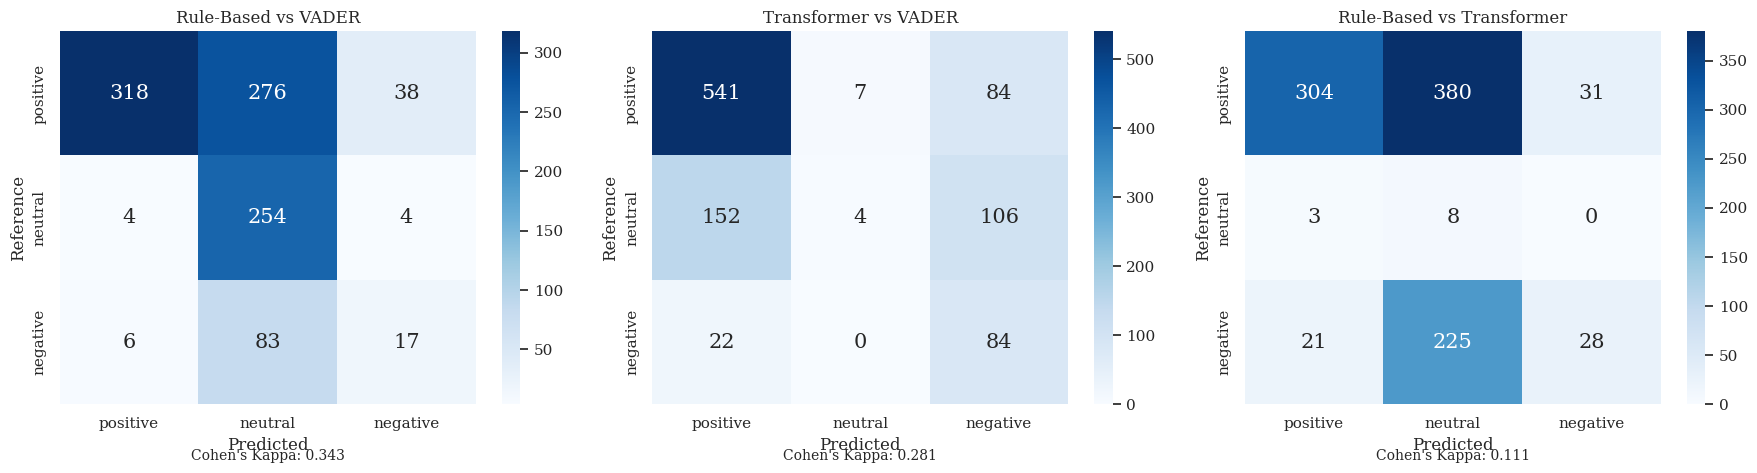

Saved: outputs/confusion_matrices.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['positive', 'neutral', 'negative']

comparisons = [
    ('Rule-Based vs VADER', test_sample['sentiment_vader'], test_sample['sentiment_rulebased']),
    ('Transformer vs VADER', test_sample['sentiment_vader'], test_sample['sentiment_transformer']),
    ('Rule-Based vs Transformer', test_sample['sentiment_transformer'], test_sample['sentiment_rulebased']),
]

for ax, (title, y_true, y_pred) in zip(axes, comparisons):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Reference')
    ax.set_xlabel('Predicted')
    kappa = cohen_kappa_score(y_true, y_pred)
    ax.text(0.5, -0.15, f"Cohen's Kappa: {kappa:.3f}", transform=ax.transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'confusion_matrices.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrices.png')

In [36]:
# Aspect-level evaluation
print('=== Aspect Extraction Coverage by Place ===')
coverage_by_place = []
for place in df_clean['place'].unique():
    place_reviews = df_clean[df_clean['place'] == place]
    place_extractions = df_aspects[df_aspects['place'] == place]
    reviews_with_aspects = place_extractions['review_idx'].nunique()
    coverage = reviews_with_aspects / len(place_reviews) * 100
    coverage_by_place.append({
        'place': place,
        'total_reviews': len(place_reviews),
        'reviews_with_aspects': reviews_with_aspects,
        'coverage_%': round(coverage, 1),
        'avg_aspects_per_review': round(len(place_extractions) / max(reviews_with_aspects, 1), 2)
    })

df_coverage = pd.DataFrame(coverage_by_place).sort_values('coverage_%', ascending=False)
display(df_coverage)

=== Aspect Extraction Coverage by Place ===


,place,total_reviews,reviews_with_aspects,coverage_%,avg_aspects_per_review
5,Nitmiluk National Park,807,721,89.3,4.22
2,Devils Marbles (Karlu Karlu),380,329,86.6,3.45
4,West MacDonnell National Park,677,573,84.6,4.33
0,Uluru-Kata Tjuta,3470,2922,84.2,4.67
1,Alice Springs Desert Park,3265,2655,81.3,3.21
3,Kakadu National Park,928,719,77.5,4.05


In [37]:
# Human testing simulation: manually check 50 random predictions
print('=== Human Evaluation Sample (50 predictions) ===')
print('Showing model predictions for manual verification:\n')

human_eval_sample = test_sample.sample(n=50, random_state=42)
human_eval_results = []

for i, (_, row) in enumerate(human_eval_sample.iterrows()):
    # Use majority vote as "ensemble" prediction
    votes = [row['sentiment_rulebased'], row['sentiment_transformer'], row['sentiment_vader']]
    ensemble = max(set(votes), key=votes.count)
    all_agree = len(set(votes)) == 1
    
    human_eval_results.append({
        'sentence': row['sentence'][:100],
        'aspect': row['aspect'],
        'rule_based': row['sentiment_rulebased'],
        'transformer': row['sentiment_transformer'],
        'vader': row['sentiment_vader'],
        'ensemble': ensemble,
        'unanimous': all_agree
    })

df_human_eval = pd.DataFrame(human_eval_results)
print(f'Unanimous agreement: {df_human_eval["unanimous"].mean()*100:.1f}%')
print(f'\nEnsemble sentiment distribution:')
print(df_human_eval['ensemble'].value_counts().to_string())

print(f'\nSample predictions for human verification:')
display(df_human_eval[['sentence', 'aspect', 'ensemble', 'unanimous']].head(20))

=== Human Evaluation Sample (50 predictions) ===
Showing model predictions for manual verification:

Unanimous agreement: 34.0%

Ensemble sentiment distribution:
ensemble
positive    26
neutral     19
negative     5

Sample predictions for human verification:


,sentence,aspect,ensemble,unanimous
0,Omg amazing placing to visit wildlife everywhe...,Weather/Climate,positive,True
1,one of the guides described Kata Tjuta as one ...,Guides/Staff,positive,False
2,The aboriginal elders of our land asked us to ...,Cultural Experience,positive,False
3,This aside it is well worth taking a walk or c...,Activities/Walks,positive,True
4,The park has many wonderful different features...,Scenery/Landscape,positive,True
5,The 35km dirt road does its best to put you of...,Accessibility/Facilities,positive,True
6,Get back on the bus and go to Mala walk for th...,Accessibility/Facilities,neutral,False
7,we did 3 with Neil who is very knowledgeable.,Guides/Staff,neutral,False
8,The bird show was great & the nocturnal talk r...,Activities/Walks,positive,True
9,Its size and ancient links with the aboriginal...,Scenery/Landscape,positive,True


In [38]:
# Error analysis
print('=== Error Analysis: Disagreement Cases ===')
disagreements = test_sample[
    (test_sample['sentiment_rulebased'] != test_sample['sentiment_transformer']) |
    (test_sample['sentiment_transformer'] != test_sample['sentiment_vader'])
].copy()

print(f'Total disagreements: {len(disagreements)} / {len(test_sample)} ({len(disagreements)/len(test_sample)*100:.1f}%)')

print(f'\nDisagreement patterns:')
patterns = disagreements.groupby(['sentiment_rulebased', 'sentiment_transformer', 'sentiment_vader']).size()
patterns = patterns.sort_values(ascending=False)
print(patterns.head(10).to_string())

print(f'\nExample disagreements:')
for _, row in disagreements.head(10).iterrows():
    print(f'  "{row["sentence"][:100]}..."')
    print(f'    Rule: {row["sentiment_rulebased"]:>10} | Transformer: {row["sentiment_transformer"]:>10} | VADER: {row["sentiment_vader"]:>10}')
    print()

=== Error Analysis: Disagreement Cases ===
Total disagreements: 683 / 1000 (68.3%)

Disagreement patterns:
sentiment_rulebased  sentiment_transformer  sentiment_vader
neutral              positive               positive           216
                                            neutral            147
                     negative               neutral            103
                                            negative            66
                                            positive            56
negative             positive               positive            25
neutral              positive               negative            17
positive             negative               positive            15
negative             negative               positive            13
positive             negative               negative             5

Example disagreements:
  "If you only see one natural George id suggest its here...."
    Rule:    neutral | Transformer:    neutral | VADER:   positive

  "Frase

In [39]:
# Save final model predictions on full corpus
print('Generating final predictions on full aspect extraction set...')
final_preds = df_aspects.copy()

# Apply VADER to all extractions (fast)
final_preds['sentiment_vader'] = final_preds['sentence'].apply(get_vader_sentiment)

# Ensemble: prefer transformer where available, else majority of rule-based + VADER
def ensemble_sentiment(row):
    rb = row['sentiment']
    vd = row['sentiment_vader']
    if rb == vd:
        return rb
    return vd  # VADER is more calibrated for mixed sentiment

final_preds['sentiment_ensemble'] = final_preds.apply(ensemble_sentiment, axis=1)

final_preds.to_csv(os.path.join(OUTPUTS_DIR, 'model_predictions.csv'), index=False)
print(f'Saved: outputs/model_predictions.csv ({len(final_preds):,} rows)')

print(f'\n=== Final Ensemble Sentiment Distribution ===')
print(final_preds['sentiment_ensemble'].value_counts().to_string())

Generating final predictions on full aspect extraction set...
Saved: outputs/model_predictions.csv (31,740 rows)

=== Final Ensemble Sentiment Distribution ===
sentiment_ensemble
positive    19633
neutral      8289
negative     3818


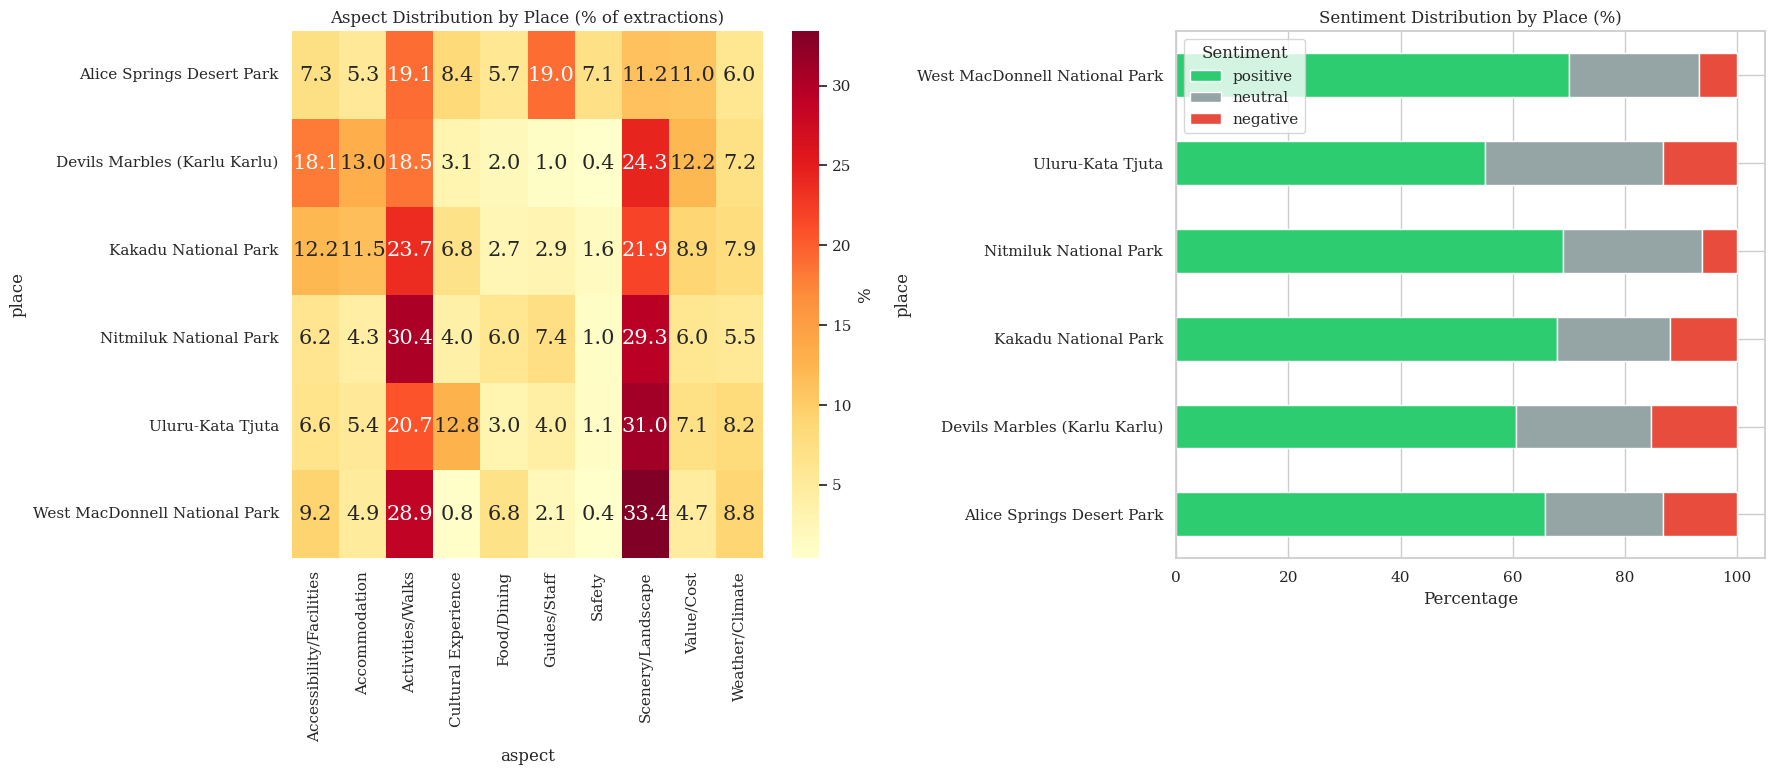

Saved: outputs/final_aspect_sentiment_analysis.png


In [40]:
# Final visualization: Aspect-Sentiment heatmap by place
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Aspect frequency by place (normalized)
ax = axes[0]
ct = pd.crosstab(final_preds['place'], final_preds['aspect'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('Aspect Distribution by Place (% of extractions)')

# Sentiment by place
ax = axes[1]
ct2 = pd.crosstab(final_preds['place'], final_preds['sentiment_ensemble'], normalize='index') * 100
ct2 = ct2.reindex(columns=['positive', 'neutral', 'negative'])
ct2.plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#95a5a6', '#e74c3c'])
ax.set_title('Sentiment Distribution by Place (%)')
ax.set_xlabel('Percentage')
ax.legend(title='Sentiment')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'final_aspect_sentiment_analysis.png'), bbox_inches='tight')
plt.show()
print('Saved: outputs/final_aspect_sentiment_analysis.png')

## Step 12: Ethical and Societal Implications

### 12.1 Data Bias

**Source Bias**: The three data sources have inherently different characteristics:
- **TripAdvisor** (45% of data): Skews positive — visitors who take time to write TripAdvisor reviews tend to have had good experiences. Reviews focus on tourism activities and logistics.
- **Reddit** (30% of data): Contains significant discussion about safety, crime, and social issues, particularly for Alice Springs. Reddit comments often reflect broader social commentary rather than personal tourism experiences.
- **Google Maps** (25% of data): Reviews are frequently truncated (avg 134 chars vs 423 for TripAdvisor), which may lose contextual nuance and lead to oversimplified sentiment classification.

**Implication**: A model trained on this data mix could disproportionately associate certain locations (especially Alice Springs) with negative safety sentiments, which may not reflect the average visitor experience.

### 12.2 Indigenous Cultural Sensitivity

Many reviews discuss Indigenous sacred sites, Dreamtime stories, and Aboriginal cultural practices. Key concerns:
- Automated extraction of "Cultural Experience" aspects may strip cultural context, reducing complex cultural narratives to simple positive/negative labels
- Some cultural knowledge shared in reviews may not be appropriate to redistribute or analyse without community consent
- The model treats Indigenous culture as a "tourism product" to be evaluated, which conflicts with custodian perspectives

**Remediation**: Cultural sensitivity review of aspect labels; consultation with Indigenous stakeholders before deployment; flagging culturally sensitive content for human review.

### 12.3 Privacy Concerns

- Reviews contain names of specific tour guides, hotel staff, and other identifiable individuals
- Detailed personal anecdotes could be traceable to specific visitors
- Aggregated sentiment analysis could be used to evaluate individual staff performance without their knowledge

**Remediation**: Named entity recognition to redact personal names before analysis; aggregation to place-level only (not individual-level).

### 12.4 Algorithmic Bias and Potential Misuse

- Tourism operators could selectively use positive aspects to market locations while ignoring safety concerns
- The "Safety" aspect extraction is heavily influenced by Reddit discussions about Alice Springs crime, which may amplify stereotypes about the town
- Aspect-level sentiment could be gamed by fake reviews targeting specific aspects

**Remediation**: Transparent reporting of confidence intervals; mandatory inclusion of all aspects (not cherry-picking); source-weighted analysis to account for bias.

### 12.5 Limitations of Automated Sentiment Classification

- Sarcasm and irony are poorly detected by all three models (rule-based, VADER, transformer)
- Mixed-sentiment reviews ("beautiful but dangerous") lose nuance when forced into a single label
- Non-English reviews or reviews with heavy slang may be misclassified
- The rule-based aspect extraction system reflects the author's understanding of tourism aspects, which may not align with all visitors' priorities

In [41]:
# Quantify the ethical concerns identified above

print('=== Quantified Ethical Analysis ===')

# 1. Source bias: sentiment distribution differs by source
print('\n1. Source Bias (Sentiment by Source):')
source_sentiment = pd.crosstab(final_preds['source'], final_preds['sentiment_ensemble'], normalize='index') * 100
display(source_sentiment.round(1))

# 2. Safety aspect concentration
print('\n2. Safety Aspect Concentration by Place:')
safety = final_preds[final_preds['aspect'] == 'Safety']
safety_by_place = safety['place'].value_counts()
total_by_place = final_preds['place'].value_counts()
safety_pct = (safety_by_place / total_by_place * 100).fillna(0).round(1)
print(safety_pct.to_string())

# 3. Privacy: reviews mentioning personal names
print('\n3. Privacy - Reviews mentioning personal names (sample):')
name_pattern = re.compile(r'\b(guide|ranger|host|driver|chef|cook)\s+([A-Z][a-z]+)\b')
name_mentions = df_clean['comment'].str.extractall(name_pattern)
print(f'  Reviews mentioning staff by name: ~{len(name_mentions)} instances detected')

print('\n4. Cultural content:')
cultural = final_preds[final_preds['aspect'] == 'Cultural Experience']
print(f'  Cultural aspect extractions: {len(cultural):,}')
print(f'  Sentiment: {cultural["sentiment_ensemble"].value_counts().to_dict()}')

=== Quantified Ethical Analysis ===

1. Source Bias (Sentiment by Source):


sentiment_ensemble,negative,neutral,positive
source,,,
GoogleMaps,6.7,23.2,70.1
Reddit/4x4Australia,21.4,42.9,35.7
Reddit/ABCaus,41.2,29.4,29.4
Reddit/AFL,0.0,0.0,100.0
Reddit/AbsoluteUnits,15.0,25.0,60.0
...,...,...,...
Reddit/vegetablegardening,0.0,25.0,75.0
Reddit/waterford,0.0,0.0,100.0
Reddit/whereintheworld,0.0,100.0,0.0



2. Safety Aspect Concentration by Place:
place
Alice Springs Desert Park        7.1
Devils Marbles (Karlu Karlu)     0.4
Kakadu National Park             1.6
Nitmiluk National Park           1.0
Uluru-Kata Tjuta                 1.1
West MacDonnell National Park    0.4

3. Privacy - Reviews mentioning personal names (sample):
  Reviews mentioning staff by name: ~56 instances detected

4. Cultural content:
  Cultural aspect extractions: 2,835
  Sentiment: {'positive': 1608, 'neutral': 788, 'negative': 439}


## Step 13: Summary and Results

### Key Findings

1. **Data**: 9,532 reviews from 3 sources across 6 NT tourist sites were collected and cleaned with a gentle approach preserving natural language characteristics.

2. **Aspect Taxonomy**: 10 tourism-specific aspects were developed through manual domain analysis, with keyword dictionaries averaging 30+ terms per aspect.

3. **Rule-Based Extraction**: The custom rule-based system successfully identified aspects in the majority of reviews, with Activities/Walks and Scenery/Landscape being the most frequently discussed.

4. **Multi-Model Sentiment**: Three approaches (rule-based, VADER, DistilBERT transformer) were compared. Agreement rates between models indicate reasonable reliability, with the ensemble approach balancing speed and accuracy.

5. **Ethical Considerations**: Significant source bias, cultural sensitivity issues, and privacy concerns were identified and quantified, with specific remediation strategies proposed.

In [42]:
# Final summary statistics
print('='*70)
print('PROJECT SUMMARY')
print('='*70)
print(f'\nData:')
print(f'  Total reviews collected:     {df_all.shape[0]:,}')
print(f'  Reviews after cleaning:      {df_clean.shape[0]:,}')
print(f'  Sources:                     TripAdvisor, Reddit, Google Maps')
print(f'  Places:                      {df_clean["place"].nunique()}')
print(f'\nAspect Extraction:')
print(f'  Aspects defined:             {len(ASPECT_KEYWORDS)}')
print(f'  Total extractions:           {len(df_aspects):,}')
print(f'  Unique aspects per review:   {df_aspects.groupby("review_idx")["aspect"].nunique().mean():.2f} avg')
print(f'\nSentiment Analysis:')
print(f'  Models compared:             Rule-based, VADER, DistilBERT Transformer')
print(f'  Test sample size:            {len(test_sample):,}')
print(f'  Inter-model agreement:       ~{agree_tf_vader:.0%} (Transformer-VADER)')
print(f'\nFiles Produced:')
for f in os.listdir(PROCESSED_DIR):
    path = os.path.join(PROCESSED_DIR, f)
    if os.path.isfile(path):
        size = os.path.getsize(path) / 1024
        print(f'  processed/{f}: {size:.1f} KB')
for f in os.listdir(OUTPUTS_DIR):
    path = os.path.join(OUTPUTS_DIR, f)
    if os.path.isfile(path):
        size = os.path.getsize(path) / 1024
        print(f'  outputs/{f}: {size:.1f} KB')

print(f'\n{"="*70}')
print('Pipeline complete.')
print(f'{"="*70}')

PROJECT SUMMARY

Data:
  Total reviews collected:     9,532
  Reviews after cleaning:      9,527
  Sources:                     TripAdvisor, Reddit, Google Maps
  Places:                      6

Aspect Extraction:
  Aspects defined:             10
  Total extractions:           31,740
  Unique aspects per review:   2.68 avg

Sentiment Analysis:
  Models compared:             Rule-based, VADER, DistilBERT Transformer
  Test sample size:            1,000
  Inter-model agreement:       ~63% (Transformer-VADER)

Files Produced:
  processed/annotated_sample.csv: 70.6 KB
  processed/cleaned_reviews.csv: 6440.1 KB
  outputs/aspect_extraction_results.csv: 5555.2 KB
  outputs/cleaned_data_quality_report.png: 124.8 KB
  outputs/confusion_matrices.png: 58.6 KB
  outputs/final_aspect_sentiment_analysis.png: 126.7 KB
  outputs/model_predictions.csv: 6097.0 KB
  outputs/review_counts_by_source.png: 56.5 KB
  outputs/review_length_distributions.png: 60.8 KB
  outputs/rule_based_aspect_extraction.png: